# Stock Price Prediction using Machine Learning

## Objective
The objective of this project is to predict the future closing price of a stock using historical market data and machine learning techniques.

## Workflow
1. Import Libraries
2. Download Stock Data
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Building
6. Evaluation
7. Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
import yfinance as yf

ticker = "AAPL"      

df = yf.download(
    ticker,
    start="2018-01-01",
    end="2025-01-01"
)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.267075,40.276427,39.565802,39.776186,102223600
2018-01-03,40.260067,40.802386,40.196955,40.330195,118071600
2018-01-04,40.447079,40.549933,40.225010,40.332536,89738400
2018-01-05,40.907581,40.994071,40.451755,40.542920,94640000
2018-01-08,40.755634,41.050168,40.657453,40.755634,82271200


In [3]:
df.shape


(1761, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1761 entries, 2018-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1761 non-null   float64
 1   (High, AAPL)    1761 non-null   float64
 2   (Low, AAPL)     1761 non-null   float64
 3   (Open, AAPL)    1761 non-null   float64
 4   (Volume, AAPL)  1761 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 82.5 KB


In [5]:
df.describe()


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1761.000000,1761.000000,1761.000000,1761.000000,1.761000e+03
mean,121.624396,122.830689,120.281371,121.502884,1.001417e+08
std,59.008726,59.477552,58.447816,58.937160,5.521309e+07
min,33.736992,34.574544,33.691911,34.161698,2.323470e+07
25%,53.993900,54.694892,53.608499,54.178659,6.309290e+07
50%,131.183517,132.668335,129.821795,131.645675,8.671200e+07
75%,168.339355,169.893745,166.905829,168.152468,1.214346e+08
max,257.375549,258.448710,255.994390,256.550832,4.265100e+08


In [6]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [7]:
df.to_csv("../data/raw/AAPL.csv")

In [8]:
df = pd.read_csv("../data/raw/AAPL.csv")

In [9]:
df.isnull().sum()

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

In [10]:
df.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [11]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2018-01-02,40.26707458496094,40.276426884472016,39.56580192963127,39.77618586634448,102223600
3,2018-01-03,40.260066986083984,40.80238628352514,40.19695500765061,40.33019497342311,118071600
4,2018-01-04,40.447078704833984,40.549932623249475,40.22500969017766,40.33253619262437,89738400


In [12]:
ticker = "AAPL"

df = yf.download(
    ticker,
    start="2018-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Remove the second level of the column names
df.columns = df.columns.get_level_values(0)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.267075,40.276427,39.565802,39.776186,102223600
2018-01-03,40.260067,40.802386,40.196955,40.330195,118071600
2018-01-04,40.447079,40.549933,40.225010,40.332536,89738400
2018-01-05,40.907581,40.994071,40.451755,40.542920,94640000
2018-01-08,40.755634,41.050168,40.657453,40.755634,82271200


In [13]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.267075,40.276427,39.565802,39.776186,102223600
2018-01-03,40.260067,40.802386,40.196955,40.330195,118071600
2018-01-04,40.447079,40.549933,40.225010,40.332536,89738400
2018-01-05,40.907581,40.994071,40.451755,40.542920,94640000
2018-01-08,40.755634,41.050168,40.657453,40.755634,82271200


In [14]:
df.to_csv("../data/raw/AAPL.csv")

In [15]:
df = pd.read_csv("../data/raw/AAPL.csv")

In [16]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

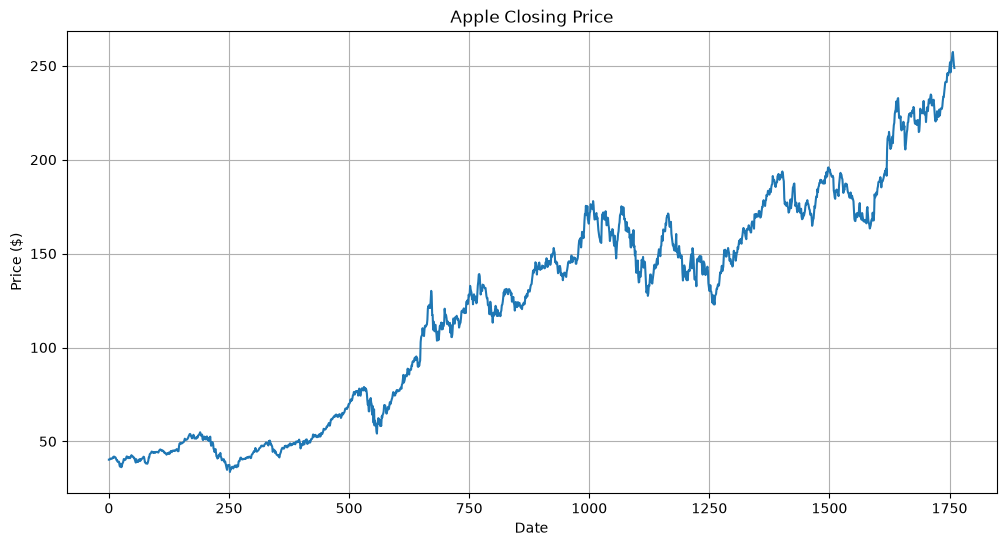

In [17]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"])
plt.title("Apple Closing Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.grid(True)
plt.show()

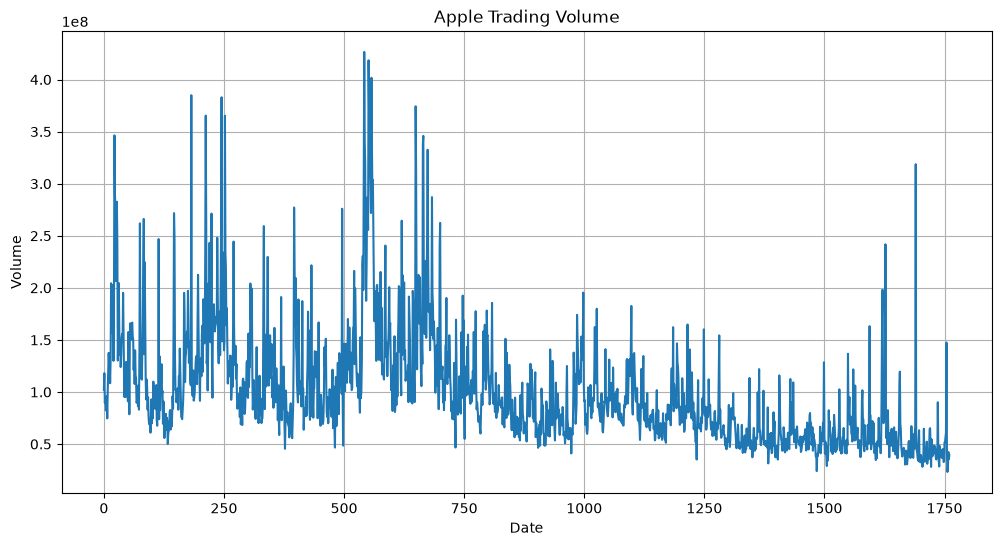

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Volume"])
plt.title("Apple Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

In [19]:
df = pd.read_csv(
    "../data/raw/AAPL.csv",
    parse_dates=["Date"],
    index_col="Date"
)

In [20]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.267075,40.276427,39.565802,39.776186,102223600
2018-01-03,40.260067,40.802386,40.196955,40.330195,118071600
2018-01-04,40.447079,40.549933,40.225010,40.332536,89738400
2018-01-05,40.907581,40.994071,40.451755,40.542920,94640000
2018-01-08,40.755634,41.050168,40.657453,40.755634,82271200


In [21]:
df["MA_5"] = df["Close"].rolling(window=5).mean()

df["MA_20"] = df["Close"].rolling(window=20).mean()

In [22]:
df.head(25)

,Close,High,Low,Open,Volume,MA_5,MA_20
Date,,,,,,,
2018-01-02,40.267075,40.276427,39.565802,39.776186,102223600,NaN,NaN
2018-01-03,40.260067,40.802386,40.196955,40.330195,118071600,NaN,NaN
2018-01-04,40.447079,40.549933,40.225010,40.332536,89738400,NaN,NaN
2018-01-05,40.907581,40.994071,40.451755,40.542920,94640000,NaN,NaN
2018-01-08,40.755634,41.050168,40.657453,40.755634,82271200,40.527487,NaN
2018-01-09,40.750950,40.921592,40.535893,40.802377,86336000,40.624262,NaN
2018-01-10,40.741596,40.743936,40.440051,40.477453,95839600,40.720568,NaN
2018-01-11,40.973026,41.022117,40.788359,40.811733,74670800,40.825758,NaN
2018-01-12,41.396122,41.459238,41.059511,41.183402,101672400,40.923466,NaN


In [23]:
df.isnull().sum()

Close      0
High       0
Low        0
Open       0
Volume     0
MA_5       4
MA_20     19
dtype: int64

In [24]:
df.dropna(inplace=True)

In [25]:
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
MA_5      0
MA_20     0
dtype: int64

In [26]:
df.to_csv("../data/processed/AAPL_processed.csv")

In [27]:
df["Target"]=df["Close"].shift(-1)

In [28]:
df.dropna(inplace=True)

In [29]:
df.tail()

,Close,High,Low,Open,Volume,MA_5,MA_20,Target
Date,,,,,,,,
2024-12-23,253.649414,254.026991,251.840961,253.152588,40858800,250.614816,243.471446,256.560852
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700,251.552829,244.729909,257.375549
2024-12-26,257.375549,258.448710,255.994390,256.550832,27237100,253.732883,245.920300,253.967377
2024-12-27,253.967377,257.057649,251.453440,256.193146,42355300,254.885516,246.946743,250.598907
2024-12-30,250.598907,251.890657,249.158116,250.628716,35557500,254.430420,247.685523,248.830215


df.columns


In [30]:
df.tail()

,Close,High,Low,Open,Volume,MA_5,MA_20,Target
Date,,,,,,,,
2024-12-23,253.649414,254.026991,251.840961,253.152588,40858800,250.614816,243.471446,256.560852
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700,251.552829,244.729909,257.375549
2024-12-26,257.375549,258.448710,255.994390,256.550832,27237100,253.732883,245.920300,253.967377
2024-12-27,253.967377,257.057649,251.453440,256.193146,42355300,254.885516,246.946743,250.598907
2024-12-30,250.598907,251.890657,249.158116,250.628716,35557500,254.430420,247.685523,248.830215


In [31]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA_5', 'MA_20', 'Target'], dtype='str')

In [32]:
X = df[["Open", "High", "Low", "Close", "Volume", "MA_5", "MA_20"]]

y = df["Target"]

In [33]:
print("X-shape:",X.shape)
print("Y-shape:",y.shape)

X-shape: (1741, 7)
Y-shape: (1741,)


In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [35]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1392, 7)
X_test : (349, 7)
y_train: (1392,)
y_test : (349,)


In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.17, 0.17, 0.16,...,-0. , 0.17, 0.17]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Open','High','Low',...,'Volume','MA_5','MA_20']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.7987
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [37]:
predictions = model.predict(X_test)

In [38]:
print(predictions[:5])

[177.87109522 178.49651085 178.03775141 177.15134574 175.72062187]


In [39]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,177.217926,177.871095
1,175.232986,178.496511
2,174.364014,178.037751
3,171.826096,177.151346
4,172.309967,175.720622
5,173.643097,174.124369
6,175.015747,175.061824
7,178.857147,176.159882
8,174.176376,178.026278
9,176.378510,177.083263


In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 2.573021262427758
MSE : 10.823767531295513
RMSE: 3.2899494724532645
R² Score: 0.9824926196930086


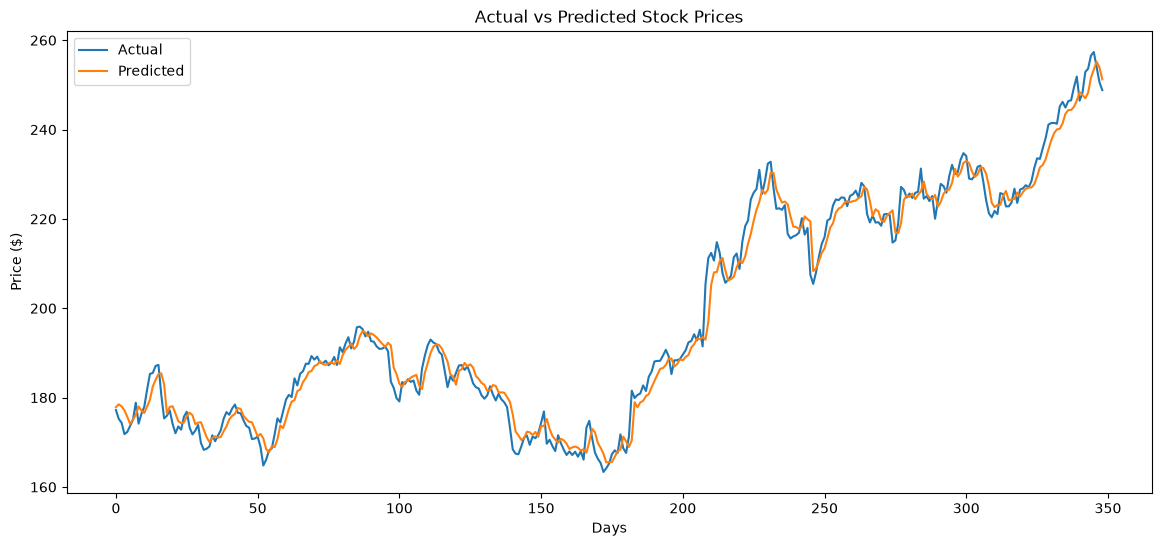

In [42]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.legend()

plt.show()

In [43]:
import joblib

joblib.dump(model, "../models/linear_regression_model.pkl")

['../models/linear_regression_model.pkl']

In [44]:
df["Daily_Return"] = df["Close"].pct_change()

In [45]:
df["Close_1"] = df["Close"].shift(1)
df["Close_2"] = df["Close"].shift(2)
df["Close_3"] = df["Close"].shift(3)
df["Close_5"] = df["Close"].shift(5)

In [46]:
df.isnull().sum()

Close           0
High            0
Low             0
Open            0
Volume          0
MA_5            0
MA_20           0
Target          0
Daily_Return    1
Close_1         1
Close_2         2
Close_3         3
Close_5         5
dtype: int64

In [47]:
df.dropna(inplace=True)

In [48]:
df.isnull().sum()

Close           0
High            0
Low             0
Open            0
Volume          0
MA_5            0
MA_20           0
Target          0
Daily_Return    0
Close_1         0
Close_2         0
Close_3         0
Close_5         0
dtype: int64

In [49]:
df["MA_10"] = df["Close"].rolling(window=10).mean()
df["MA_50"] = df["Close"].rolling(window=50).mean()

In [50]:
df["Volatility"] = df["Daily_Return"].rolling(window=20).std()

In [51]:
df.isnull().sum()

Close            0
High             0
Low              0
Open             0
Volume           0
MA_5             0
MA_20            0
Target           0
Daily_Return     0
Close_1          0
Close_2          0
Close_3          0
Close_5          0
MA_10            9
MA_50           49
Volatility      19
dtype: int64

In [52]:
df.dropna(inplace=True)

In [53]:
df.isnull().sum()

Close           0
High            0
Low             0
Open            0
Volume          0
MA_5            0
MA_20           0
Target          0
Daily_Return    0
Close_1         0
Close_2         0
Close_3         0
Close_5         0
MA_10           0
MA_50           0
Volatility      0
dtype: int64

In [54]:
df.to_csv("../data/processed/AAPL_processed.csv")

In [55]:
X = df[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "MA_5",
        "MA_10",
        "MA_20",
        "MA_50",
        "Daily_Return",
        "Volatility",
        "Close_1",
        "Close_2",
        "Close_3",
        "Close_5"
    ]
]

y = df["Target"]

In [56]:
print(X.shape)
print(y.shape)

(1687, 15)
(1687,)


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [58]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, lr_predictions)
rmse = mean_squared_error(y_test, lr_predictions) ** 0.5
r2 = r2_score(y_test, lr_predictions)

print("Linear Regression")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

Linear Regression
MAE : 3.3394822530539625
RMSE: 4.183727606949555
R² : 0.9717716316646855


In [60]:
from sklearn.ensemble import RandomForestRegressor

In [61]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [62]:
rf_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [63]:
rf_predictions=rf_model.predict(X_test)

In [64]:
mae = mean_absolute_error(y_test, rf_predictions)
rmse = mean_squared_error(y_test, rf_predictions) ** 0.5
r2 = r2_score(y_test, rf_predictions)

print("Random Forest")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

Random Forest
MAE : 17.02237626792411
RMSE: 25.48170803822309
R² : -0.04716723425607583


In [65]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1349, 15)
(338, 15)
(1349,)
(338,)


In [66]:
print(X_train.head())

                 Open       High        Low      Close     Volume       MA_5  \
Date                                                                           
2018-04-18  41.733907  41.970967  41.515627  41.740948   83018000  41.345217   
2018-04-19  40.783319  41.165898  40.525139  40.557999  139235200  41.282316   
2018-04-20  40.041629  40.187149  38.828172  38.896240  261964400  40.859367   
2018-04-23  39.156766  39.177889  38.513658  38.783577  146062000  40.362717   
2018-04-24  38.884507  39.039417  37.840045  38.243748  134768000  39.644502   

                MA_10      MA_20      MA_50  Daily_Return  Volatility  \
Date                                                                    
2018-04-18  40.785432  40.191847  40.404120     -0.002244    0.018296   
2018-04-19  40.785432  40.209802  40.453090     -0.028340    0.018720   
2018-04-20  40.722999  40.173070  40.485141     -0.040972    0.020691   
2018-04-23  40.610102  40.176590  40.535463     -0.002897    0.020020   
2

In [67]:
print(y_train.head())

Date
2018-04-18    40.557999
2018-04-19    38.896240
2018-04-20    38.783577
2018-04-23    38.243748
2018-04-24    38.410397
Name: Target, dtype: float64


In [68]:
print(X_train.isnull().sum())

Open            0
High            0
Low             0
Close           0
Volume          0
MA_5            0
MA_10           0
MA_20           0
MA_50           0
Daily_Return    0
Volatility      0
Close_1         0
Close_2         0
Close_3         0
Close_5         0
dtype: int64


In [69]:
df[["Close", "Target"]].head(10)

,Close,Target
Date,,
2018-04-18,41.740948,40.557999
2018-04-19,40.557999,38.896240
2018-04-20,38.896240,38.783577
2018-04-23,38.783577,38.243748
2018-04-24,38.243748,38.410397
2018-04-25,38.410397,38.544189
2018-04-26,38.544189,38.098244
2018-04-27,38.098244,38.788269
2018-04-30,38.788269,39.689568


In [70]:
df["Target"] = df["Close"].shift(-1)

In [71]:
df.dropna(inplace=True)

In [72]:
X = df[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "MA_5",
        "MA_10",
        "MA_20",
        "MA_50",
        "Daily_Return",
        "Volatility",
        "Close_1",
        "Close_2",
        "Close_3",
        "Close_5"
    ]
]

In [73]:
y = df["Target"]

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [75]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

In [76]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [77]:
mae = mean_absolute_error(y_test, rf_predictions)
rmse = mean_squared_error(y_test, rf_predictions) ** 0.5
r2 = r2_score(y_test, rf_predictions)

print("Random Forest")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

Random Forest
MAE : 16.75106457862628
RMSE: 25.1396944543227
R² : -0.02921633331951523


In [78]:
print(df[["Close", "Target"]].tail(10))

                 Close      Target
Date                              
2024-12-13  246.554764  249.446259
2024-12-16  249.446259  251.870789
2024-12-17  251.870789  246.475281
2024-12-18  246.475281  248.204208
2024-12-19  248.204208  252.874390
2024-12-20  252.874390  253.649414
2024-12-23  253.649414  256.560852
2024-12-24  256.560852  257.375549
2024-12-26  257.375549  253.967377
2024-12-27  253.967377  250.598907


In [79]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1348, 15)
(338, 15)
(1348,)
(338,)


In [80]:
print(X.dtypes)

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
MA_5            float64
MA_10           float64
MA_20           float64
MA_50           float64
Daily_Return    float64
Volatility      float64
Close_1         float64
Close_2         float64
Close_3         float64
Close_5         float64
dtype: object


In [81]:
print(X.isnull().sum())

Open            0
High            0
Low             0
Close           0
Volume          0
MA_5            0
MA_10           0
MA_20           0
MA_50           0
Daily_Return    0
Volatility      0
Close_1         0
Close_2         0
Close_3         0
Close_5         0
dtype: int64


In [82]:
print("Actual")
print(y_test.head(10).values)

print("Predicted")
print(rf_predictions[:10])

Actual
[177.93878174 181.81965637 185.30560303 185.52279663 187.09294128
 187.3299408  180.62477112 175.34159851 175.95387268 177.11914062]
Predicted
[176.14569672 175.87502441 179.64523621 183.62278046 184.17199585
 186.90555511 186.74579788 183.15470413 173.46980194 175.99557907]


In [83]:
print(y_test.head())
print(rf_predictions[:5])

Date
2023-08-25    177.938782
2023-08-28    181.819656
2023-08-29    185.305603
2023-08-30    185.522797
2023-08-31    187.092941
Name: Target, dtype: float64
[176.14569672 175.87502441 179.64523621 183.62278046 184.17199585]


In [84]:
print("Training Close Range")
print(X_train["Close"].min(), X_train["Close"].max())

print("\nTesting Close Range")
print(X_test["Close"].min(), X_test["Close"].max())

Training Close Range
33.73699188232422 193.7340087890625

Testing Close Range
163.36143493652344 257.37554931640625


In [85]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

         Feature  Importance
8          MA_50    0.316339
7          MA_20    0.307335
3          Close    0.119630
0           Open    0.087180
1           High    0.070682
2            Low    0.052321
5           MA_5    0.018423
11       Close_1    0.017125
12       Close_2    0.008749
6          MA_10    0.001303
10    Volatility    0.000301
14       Close_5    0.000161
4         Volume    0.000155
9   Daily_Return    0.000150
13       Close_3    0.000145


In [86]:
import os
print(os.getcwd())

C:\Users\hitar\OneDrive\Desktop\stock  price prediction\notebooks


In [87]:
import os

print(os.path.exists("../src/feature_engineering.py"))

True


In [88]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

C:\Users\hitar\OneDrive\Desktop\stock  price prediction


In [89]:
from src.feature_engineering import create_features

In [90]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA_5', 'MA_20', 'Target',
       'Daily_Return', 'Close_1', 'Close_2', 'Close_3', 'Close_5', 'MA_10',
       'MA_50', 'Volatility'],
      dtype='str')


In [91]:
print(df.dtypes)

Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
MA_5            float64
MA_20           float64
Target          float64
Daily_Return    float64
Close_1         float64
Close_2         float64
Close_3         float64
Close_5         float64
MA_10           float64
MA_50           float64
Volatility      float64
dtype: object


In [92]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'MA_5', 'MA_20', 'Target',
       'Daily_Return', 'Close_1', 'Close_2', 'Close_3', 'Close_5', 'MA_10',
       'MA_50', 'Volatility'],
      dtype='str')


In [93]:
stocks = ["AAPL", "MSFT", "GOOG", "AMZN", "TSLA"]
for stock in stocks:
    df = yf.download(
        stock,
        start="2018-01-01",
        end="2025-01-01",
        auto_adjust=True
    )

    df.to_csv(f"../data/raw/{stock}.csv")

print("All stock data downloaded successfully!")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

All stock data downloaded successfully!


In [94]:
from src.data_loader import load_data
from src.feature_engineering import create_features

stocks = ["AAPL", "MSFT", "GOOG", "AMZN", "TSLA"]

for stock in stocks:
    # Load raw data
    df = load_data(f"../data/raw/{stock}.csv")

    # Create features
    df = create_features(df)

    # Create target
    df["Target"] = df["Close"].shift(-1)

    # Remove NaN rows
    df.dropna(inplace=True)

    # Save processed data
    df.to_csv(f"../data/processed/{stock}_processed.csv")

    print(f"{stock} processed successfully!")

print("All stocks processed successfully!")

AAPL processed successfully!
MSFT processed successfully!
GOOG processed successfully!
AMZN processed successfully!
TSLA processed successfully!
All stocks processed successfully!


In [97]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from src.data_loader import load_data
from src.feature_engineering import create_features
from src.train import train_model

import json

stocks = ["AAPL", "MSFT", "GOOG", "AMZN", "TSLA"]

for stock in stocks:
    print(f"\nTraining {stock}...")

    df = load_data(f"../data/raw/{stock}.csv")
    df = create_features(df)

    model, mae, rmse, r2 = train_model(
        df,
        model_name=f"{stock}_model.pkl"
    )

    metrics = {
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4)
    }

    with open(f"../models/{stock}_metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)

print("✅ All models and metrics saved successfully!")


Training AAPL...
Model Performance
MAE  : 3.3121
RMSE : 4.1556
R²   : 0.9721
Model saved at: C:\Users\hitar\OneDrive\Desktop\stock  price prediction\models\AAPL_model.pkl
Model saved successfully!

Training MSFT...
Model Performance
MAE  : 5.6633
RMSE : 7.0124
R²   : 0.9660
Model saved at: C:\Users\hitar\OneDrive\Desktop\stock  price prediction\models\MSFT_model.pkl
Model saved successfully!

Training GOOG...
Model Performance
MAE  : 2.9132
RMSE : 3.9215
R²   : 0.9565
Model saved at: C:\Users\hitar\OneDrive\Desktop\stock  price prediction\models\GOOG_model.pkl
Model saved successfully!

Training AMZN...
Model Performance
MAE  : 3.3807
RMSE : 4.3803
R²   : 0.9707
Model saved at: C:\Users\hitar\OneDrive\Desktop\stock  price prediction\models\AMZN_model.pkl
Model saved successfully!

Training TSLA...
Model Performance
MAE  : 9.8014
RMSE : 14.2874
R²   : 0.9463
Model saved at: C:\Users\hitar\OneDrive\Desktop\stock  price prediction\models\TSLA_model.pkl
Model saved successfully!
✅ All mod

In [98]:
from src.data_loader import load_data
from src.feature_engineering import create_features
from src.train import train_model

stocks = ["AAPL", "MSFT", "GOOG", "AMZN", "TSLA"]

for stock in stocks:
    print(f"\nTraining {stock}...")

    df = load_data(f"../data/raw/{stock}.csv")
    df = create_features(df)

    # Save model with stock name
    train_model(df, model_name=f"{stock}_model.pkl")

print("\n✅ All models trained successfully!")


Training AAPL...
Model Performance
MAE  : 3.3121
RMSE : 4.1556
R²   : 0.9721
Model saved at: C:\Users\hitar\OneDrive\Desktop\stock  price prediction\models\AAPL_model.pkl
Model saved successfully!

Training MSFT...
Model Performance
MAE  : 5.6633
RMSE : 7.0124
R²   : 0.9660
Model saved at: C:\Users\hitar\OneDrive\Desktop\stock  price prediction\models\MSFT_model.pkl
Model saved successfully!

Training GOOG...
Model Performance
MAE  : 2.9132
RMSE : 3.9215
R²   : 0.9565
Model saved at: C:\Users\hitar\OneDrive\Desktop\stock  price prediction\models\GOOG_model.pkl
Model saved successfully!

Training AMZN...
Model Performance
MAE  : 3.3807
RMSE : 4.3803
R²   : 0.9707
Model saved at: C:\Users\hitar\OneDrive\Desktop\stock  price prediction\models\AMZN_model.pkl
Model saved successfully!

Training TSLA...
Model Performance
MAE  : 9.8014
RMSE : 14.2874
R²   : 0.9463
Model saved at: C:\Users\hitar\OneDrive\Desktop\stock  price prediction\models\TSLA_model.pkl
Model saved successfully!

✅ All mo